In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
from sklearn.preprocessing import StandardScaler


In [9]:
# drive.mount('/content/drive', force_remount=True )
# df = pd.read_csv('/content/drive/My Drive/E-commerce  cosmetic dataset.csv', encoding='latin-1')
# print( df.shape )
from pathlib import Path
DATA_PATH = Path('data/E-commercecosmeticdataset.csv')

df = pd.read_csv(DATA_PATH, encoding='latin-1')
print(df.shape)

(12615, 15)


In [10]:
df.head()

,product_name,website,country,category,subcategory,title-href,price,brand,ingredients,form,type,color,size,rating,noofratings
0,"Carlton London Incense Eau da parfum, Premium ...",Flipkart,India,body,perfume,https://www.amazon.in/Carlton-London-Limited-I...,599.0,Carlton London,NaN,aerosol,NaN,"Top Note: Orange Blossom, Blackberry | Heart N...",100,3.9,19
1,CHARLENE SPRAY MIST PERFUME 30 - INTIMATE (PAC...,Flipkart,India,body,perfume,https://www.amazon.in/CHARLENE-SPRAY-MIST-PERF...,149.0,Charlene,NaN,aerosol,NaN,Unit count type:,30,4.4,"4,031"
2,CHARLENE SPRAY MIST PERFUME 30 - INTIMATE (PAC...,Flipkart,India,body,perfume,https://www.amazon.in/CHARLENE-SPRAY-MIST-PERF...,298.0,Charlene,NaN,aerosol,NaN,Unit count type:,30,4.4,"4,072"
3,DENVER Black Code Perfume - 60 | Eau de Parfum...,Flipkart,India,body,perfume,https://www.amazon.in/DENVER-Black-Code-Perfum...,245.0,Denver,NaN,aerosol,NaN,Long-Lasting Scent,60,4.2,61
4,Denver Hamilton Perfume - 100 | Long Lasting P...,Flipkart,India,body,perfume,https://www.amazon.in/Denver-Perfume-Hamilton-...,422.0,Denver,NaN,aerosol,NaN,Long-Lasting Scent,100,4.3,342


In [11]:
print(df.shape)
print(df.isnull().sum())

(12615, 15)
product_name       0
website            0
country            0
category           0
subcategory        0
title-href         0
price            317
brand              0
ingredients     6015
form               0
type            2681
color           1989
size            3166
rating          2067
noofratings      459
dtype: int64


**Data Cleaning**

In [12]:
df = df.drop(columns=['product_name','title-href', 'ingredients'])

In [13]:
print(df['type'].value_counts())

type
all                               5158
matte                              572
combination, dry, normal, oily     528
shimmer                            447
Combination, Dry, Normal, Oily     381
                                  ... 
Full Cover,Full                      1
combinational,sensitive              1
Lightweight Formula,Full             1
Face                                 1
fine, damaged                        1
Name: count, Length: 133, dtype: int64


In [14]:
print(df['color'].value_counts())

color
No color            4197
Black                440
Multicolor           192
No colour            161
Pink                 149
                    ... 
Snowball               1
5. Lustrous Nude       1
Certainly Red          1
Power Move             1
Selfie Queen           1
Name: count, Length: 3357, dtype: int64


In [15]:
size_counts = df['size'].value_counts()
print(size_counts)

size
30             835
100            435
200            349
50             317
51             298
              ... 
1.4 s            1
0.19 Pounds      1
13 s             1
0.14 Kilos       1
47               1
Name: count, Length: 700, dtype: int64


In [16]:
# dropping columns w/ inconsistencies
df = df.drop(columns=['size','color','type'])

In [17]:
# dropping null rows
df = df.dropna(subset=['price'])

7.7846953906338525

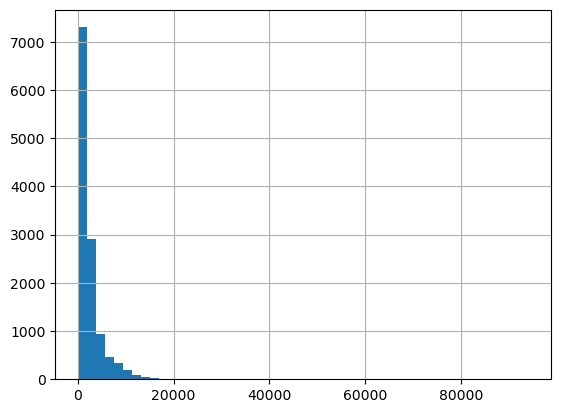

In [18]:
# need to check price distribution to see if outliers are majorly affecting
df['price'].describe()
df['price'].hist(bins=50)
df['price'].skew()

In [19]:
# handle outliers
# get quantile of .25
q1 = df['price'].quantile(0.25)
# quantile of .75
q3 = df['price'].quantile(0.75)
# iqr = .75 -.25
iqr = q3 - q1

# print(q1, q3, iqr)
# 3rd quartile + IQR * 1.5
upper_threshold = q3 + iqr * 1.5

# 1st quartile - IQR * 1.5
lower_threshold = q1 - iqr * 1.5

# print(upper_threshold, lower_threshold)

outliers = df[(df['price'] > upper_threshold) | (df['price'] < lower_threshold) ]
print(outliers['price'].sort_values())

# only keep the values that are not outliers
df = df[(df['price'] >= lower_threshold) & (df['price'] <= upper_threshold)]


1755      6450.00
1363      6450.00
644       6454.30
794       6454.30
1026      6454.30
           ...   
3536     57289.29
892      61400.00
8420     69000.00
11156    87666.00
893      94099.00
Name: price, Length: 960, dtype: float64


1.1524540767675169

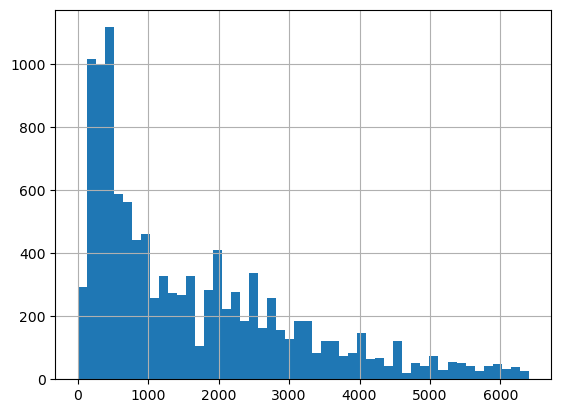

In [20]:
# see if removing outliers fixed it
df['price'].describe()
df['price'].hist(bins=50)
df['price'].skew()

In [21]:
for x in df.columns:
  print( str( type( df[x].iloc[0] ) ) + ": " + x )

<class 'str'>: website
<class 'str'>: country
<class 'str'>: category
<class 'str'>: subcategory
<class 'numpy.float64'>: price
<class 'str'>: brand
<class 'str'>: form
<class 'str'>: rating
<class 'str'>: noofratings


In [22]:
noofratings_counts = df['noofratings'].value_counts()
print(noofratings_counts)

noofratings
0             610
No reviews    458
11            296
14            294
1             287
             ... 
3,899           1
7,616           1
2,521           1
1,760           1
587             1
Name: count, Length: 1945, dtype: int64


In [23]:
# fix no reviews and convert to numeric
df['noofratings'] = df['noofratings'].replace('No reviews', 0)
df['noofratings'] = pd.to_numeric(df['noofratings'], errors='coerce')

In [24]:
# log transform then fill nulls with log median
df['noofratings'] = np.log1p(df['noofratings'])
df['noofratings'] = df['noofratings'].fillna(df['noofratings'].median())

In [25]:
df['noofratings'].describe()

count    11338.000000
mean         3.507073
std          2.037863
min          0.000000
25%          2.484907
50%          3.258097
75%          4.787492
max         11.770733
Name: noofratings, dtype: float64

In [26]:
# convert to numeric and fill w median because we haven't removed outliers yet
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'] = df['rating'].fillna(df['rating'].median())
print(df['rating'].isnull().sum())

0


In [27]:
df['rating'].describe()

count    11338.000000
mean         4.809374
std         17.854969
min          1.000000
25%          4.020000
50%          4.200000
75%          4.400000
max        925.000000
Name: rating, dtype: float64

In [28]:
# i can assume outliers are wrong bc ratings shold only be 0-5
# remove with IQR
# get quantile of .25
q1 = df['rating'].quantile(0.25)
# quantile of .75
q3 = df['rating'].quantile(0.75)
# iqr = .75 -.25
iqr = q3 - q1

# print(q1, q3, iqr)
# 3rd quartile + IQR * 1.5
upper_threshold = q3 + iqr * 1.5

# 1st quartile - IQR * 1.5
lower_threshold = q1 - iqr * 1.5

# print(upper_threshold, lower_threshold)

outliers = df[(df['rating'] > upper_threshold) | (df['rating'] < lower_threshold) ]
print(outliers['rating'].sort_values())

# only keep the values that are not outliers
df = df[(df['rating'] >= lower_threshold) & (df['rating'] <= upper_threshold)]


4563       1.0
6511       1.0
7935       1.0
11046      1.0
6497       1.0
         ...  
590      506.0
561      536.0
593      676.0
509      895.0
488      925.0
Name: rating, Length: 1424, dtype: float64


In [29]:
df['rating'].describe()

count    9914.000000
mean        4.221281
std         0.275914
min         3.450000
25%         4.100000
50%         4.200000
75%         4.400000
max         4.900000
Name: rating, dtype: float64

In [30]:
scaler = StandardScaler()
df[['rating', 'noofratings']] = scaler.fit_transform(
    df[['rating', 'noofratings']]
)

In [31]:
print(df['country'].value_counts())
print(df['website'].value_counts())

country
India    6922
USA      2992
Name: count, dtype: int64
website
Amazon      3678
ulta        2992
Sephora     2057
Flipkart    1110
sephora       77
Name: count, dtype: int64


In [32]:
print(df['category'].value_counts())
print(df['subcategory'].value_counts())

category
lips        2112
eyes        1915
skincare    1873
body        1813
hair        1307
face         894
Name: count, dtype: int64
subcategory
perfume          871
serum            854
lipstick         776
eyeshadow        637
mascara          531
bodywash         495
lipbalm          446
shampoo          442
soap             431
eyeliner         419
lipgloss         411
lipliner         405
hairmask         404
blush            351
moisturizer      340
concealer        304
cleanser         271
eyebrow          206
oil              194
face wash        163
mask             161
foundation       160
toner            124
primer           110
dry shampoo       81
lipstain          74
eye treatment     68
powder            39
conditioner       37
hairstyling       30
spray             29
highlighter       18
sunscreen         14
eye primer        13
face oil           4
eyelashes          1
Name: count, dtype: int64


In [33]:
print(df['brand'].value_counts())
print(df['form'].value_counts())

brand
Sephora Collection         435
Maybelline                 143
SWISS BEAUTY               129
Too Faced                  116
Anastasia Beverly Hills    112
                          ... 
Mixed Chicks                 1
Mojocare                     1
Montagne Jeunesse            1
Mukti Gold                   1
Homeo Essentials             1
Name: count, Length: 1533, dtype: int64
form
liquid     3956
cream      2175
stick       808
powder      693
pencil      563
other       488
gel         472
solid       468
crayon       96
dry          81
pen          26
aerosol      18
foam         15
mask         13
lotion       11
tube         11
mousse       10
strip         4
gaze          2
capsule       1
paste         1
wipes         1
cushion       1
Name: count, dtype: int64


In [34]:
df.head()

,website,country,category,subcategory,price,brand,form,rating,noofratings
0,Flipkart,India,body,perfume,599.0,Carlton London,aerosol,-1.164484,-0.318578
1,Flipkart,India,body,perfume,149.0,Charlene,aerosol,0.647768,-0.192488
2,Flipkart,India,body,perfume,298.0,Charlene,aerosol,0.647768,-0.192488
3,Flipkart,India,body,perfume,245.0,Denver,aerosol,-0.077133,0.225164
4,Flipkart,India,body,perfume,422.0,Denver,aerosol,0.285317,1.047260


In [35]:
# need to encode website, country, category. not sure about form, brand, subcategory
# binary encode country
df['country'] = df['country'].map({'India': 0, 'USA': 1})

In [36]:
# check unique values for categorical
for col in ['website', 'country']:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().head(10))
    print(" ")

website: 5 unique values
website
Amazon      3678
ulta        2992
Sephora     2057
Flipkart    1110
sephora       77
Name: count, dtype: int64
 
country: 2 unique values
country
0    6922
1    2992
Name: count, dtype: int64
 


In [37]:
# fix sephora and Sephora to be same
df['website'] = df['website'].str.lower().str.strip()
df['website'].unique()

array(['flipkart', 'ulta', 'sephora', 'amazon'], dtype=object)

In [38]:
df['website'].value_counts()

website
amazon      3678
ulta        2992
sephora     2134
flipkart    1110
Name: count, dtype: int64

In [39]:
# one hot encode website ,category w/ pandas. make numeric
# https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/

df = pd.get_dummies(df,columns=['website', 'category'],dtype=int)

In [40]:
df.head()

,country,subcategory,price,brand,form,rating,noofratings,website_amazon,website_flipkart,website_sephora,website_ulta,category_body,category_eyes,category_face,category_hair,category_lips,category_skincare
0,0,perfume,599.0,Carlton London,aerosol,-1.164484,-0.318578,0,1,0,0,1,0,0,0,0,0
1,0,perfume,149.0,Charlene,aerosol,0.647768,-0.192488,0,1,0,0,1,0,0,0,0,0
2,0,perfume,298.0,Charlene,aerosol,0.647768,-0.192488,0,1,0,0,1,0,0,0,0,0
3,0,perfume,245.0,Denver,aerosol,-0.077133,0.225164,0,1,0,0,1,0,0,0,0,0
4,0,perfume,422.0,Denver,aerosol,0.285317,1.047260,0,1,0,0,1,0,0,0,0,0


**Clustering**

In [41]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [42]:
features = ['country', 'rating', 'noofratings', 'website_flipkart',
            'website_amazon','website_sephora', 'website_ulta', 'category_eyes',
            'category_face', 'category_hair', 'category_lips', 'category_skincare']
df[features].describe()

,country,rating,noofratings,website_flipkart,website_amazon,website_sephora,website_ulta,category_eyes,category_face,category_hair,category_lips,category_skincare
count,9914.000000,9.914000e+03,9.914000e+03,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,0.301795,-3.417256e-15,1.376076e-16,0.111963,0.370991,0.215251,0.301795,0.193161,0.090176,0.131834,0.213032,0.188925
std,0.459060,1.000050e+00,1.000050e+00,0.315337,0.483094,0.411017,0.459060,0.394798,0.286447,0.338327,0.409471,0.391469
min,0.000000,-2.795511e+00,-1.758298e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-4.395835e-01,-5.256079e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,-7.713313e-02,-1.924879e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,6.477677e-01,6.561313e-01,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,2.460020e+00,3.898605e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
k_range = range(2,10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(df[features])

    score = silhouette_score(df[features], labels)
    print(f'k={k}: Silhouette = {score:.3f}')

k=2: Silhouette = 0.207
k=3: Silhouette = 0.261
k=4: Silhouette = 0.248
k=5: Silhouette = 0.281
k=6: Silhouette = 0.298
k=7: Silhouette = 0.275
k=8: Silhouette = 0.329
k=9: Silhouette = 0.330


In [44]:
# run kmeans
kmeans = KMeans(n_clusters=6, random_state=0)
df['cluster'] = kmeans.fit_predict(df[features])

In [45]:
df.groupby('cluster')[features].mean() # look at avg of each feature in each cluster


,country,rating,noofratings,website_flipkart,website_amazon,website_sephora,website_ulta,category_eyes,category_face,category_hair,category_lips,category_skincare
cluster,,,,,,,,,,,,
0,0.306856,-1.711918,0.032095,0.045987,0.484114,0.163043,0.306856,0.245819,0.311037,0.041806,0.226589,0.056856
1,0.002597,-0.157550,-0.463166,0.000000,0.000000,0.997403,0.002597,0.223896,0.005195,0.036883,0.322597,0.262857
2,0.037479,-0.261446,1.517489,0.080068,0.882453,0.000000,0.037479,0.353492,0.008518,0.073254,0.477002,0.079216
3,0.011747,-0.007765,-1.096687,0.000000,0.988253,0.000000,0.011747,0.250122,0.185512,0.367107,0.190896,0.000000
4,0.974418,0.967496,0.370221,0.001527,0.016800,0.007255,0.974418,0.100802,0.046964,0.133639,0.103093,0.349752
5,0.000000,0.145942,0.357993,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.303030


In [46]:
# add price to see if clusters relate to price
print(df.groupby('cluster')['price'].mean().sort_values())

cluster
5     534.586531
3     864.863059
2    1336.377879
0    1494.068227
4    2155.662944
1    2359.969143
Name: price, dtype: float64


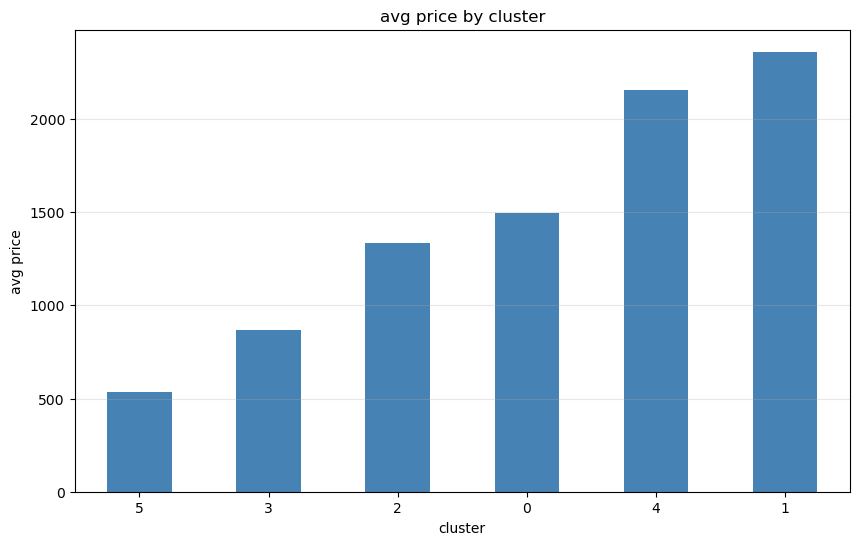

In [47]:
plot.figure(figsize=(10, 6))
df.groupby('cluster')['price'].mean().sort_values().plot(kind='bar', color='steelblue')
plot.xlabel('cluster')
plot.ylabel('avg price')
plot.title('avg price by cluster')
plot.xticks(rotation=0)
plot.grid(axis='y', alpha=0.3)
plot.show()